# Rail Network And Stations

This notebook uses the project CLI. Network fetch remains manual. Stations now run in two explicit stages: `fetch` downloads the raw payload, and `preprocess` turns it into clean outputs. Station `assemble` is intentionally left for later.

In [22]:
from __future__ import annotations

import json
import subprocess
import sys
from pathlib import Path

import geopandas as gpd


def find_repo_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src").exists() and (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("Could not locate repository root.")


REPO_ROOT = find_repo_root()
CLI = REPO_ROOT / "src" / "cli.py"


def run_cli(*args: str) -> dict:
    result = subprocess.run(
        [sys.executable, str(CLI), *args],
        cwd=REPO_ROOT,
        check=True,
        capture_output=True,
        text=True,
    )
    return json.loads(result.stdout)

## Network

In [23]:
network_fetch = run_cli("data", "network", "fetch")
network_fetch

{'domain': 'network',
 'stage': 'fetch',
 'warning': 'Network fetch is not implemented here. Download the Trafikverket GeoPackage manually and place it in data/network/raw.'}

In [24]:
network_result = run_cli("data", "network", "preprocess")
network_result

{'domain': 'network',
 'stage': 'preprocess',
 'summary': {'rows': 515,
  'columns': 11,
  'crs': 'EPSG:4326',
  'bounds': [11.170355174038386,
   55.367495546331305,
   24.15073285716132,
   68.43404058958804]},
 'summary_path': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/network/processed/network_summary.json'}

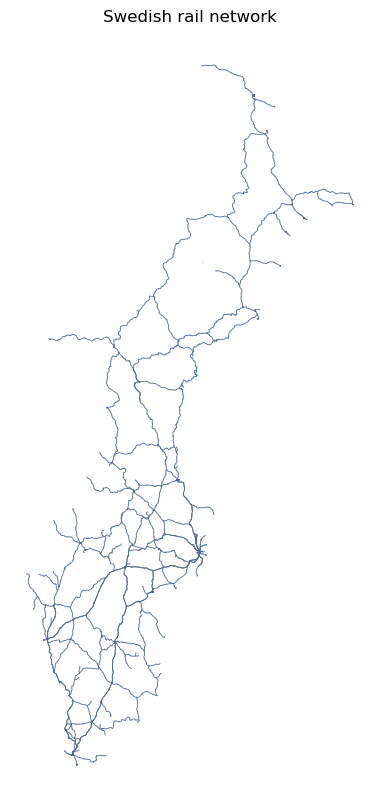

In [25]:
network = gpd.read_file(REPO_ROOT / "data/network/raw/Järnvägsnät_bandel_aggregat_GeoPackage/Järnvägsnät_bandel_aggregat_GeoPackage.gpkg")
network = network.to_crs(4326) if network.crs else network
ax = network.plot(figsize=(10, 10), linewidth=0.6, color="#4C6A92")
ax.set_title("Swedish rail network")
ax.set_axis_off()

## Stations

In [26]:
STATION_FILTERS = {
    "country_code": "SE",
    "location_signature": None,
    "advertised": None,
    "prognosticated": None,
}
STATION_FILTERS

{'country_code': 'SE',
 'location_signature': None,
 'advertised': None,
 'prognosticated': None}

In [27]:
station_fetch_args = ["data", "stations", "fetch"]
for key, value in STATION_FILTERS.items():
    if value is not None:
        station_fetch_args.extend([f"--{key.replace('_', '-')}", str(value)])

station_fetch_result = run_cli(*station_fetch_args)
station_fetch_result

{'domain': 'stations',
 'stage': 'fetch',
 'raw_path': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/stations/raw/train_stations_sweden.json',
 'filters': {'country_code': 'SE',
  'location_signature': None,
  'advertised': None,
  'prognosticated': None},
 'rows': 1636}

In [28]:
station_preprocess_args = ["data", "stations", "preprocess"]
for key, value in STATION_FILTERS.items():
    if value is not None:
        station_preprocess_args.extend([f"--{key.replace('_', '-')}", str(value)])

station_preprocess_result = run_cli(*station_preprocess_args)
station_preprocess_result

{'domain': 'stations',
 'stage': 'preprocess',
 'rows': 1636,
 'filters': {'country_code': 'SE',
  'location_signature': None,
  'advertised': None,
  'prognosticated': None},
 'saved': {'geojson': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/stations/processed/train_stations_sweden.geojson',
  'csv': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/stations/processed/train_stations_sweden.csv'}}

In [29]:
stations_gdf = gpd.read_file(REPO_ROOT / station_preprocess_result["saved"]["geojson"])
stations_gdf.head(10)

,LocationSignature,AdvertisedLocationName,OfficialLocationName,AdvertisedShortLocationName,CountryCode,PrimaryLocationCode,Advertised,Prognosticated,county_numbers,platform_lines,LocationInformationText,ModifiedTime,geometry_wkt,CountyNo,PlatformLine,geometry
0,A,Alingsås,Alingsås,Alingsås,SE,119,True,True,14,"1,2,3,4",Spåruppgifterna är preliminära och kan ändras.,2026-06-03 11:10:25.300000+00:00,POINT (12.532185446104254 57.92690516743591),[14.0],"[1, 2, 3, 4]",POINT (12.53219 57.92691)
1,Aal,Annedal,Annedal,Annedal,SE,10008,False,False,12,nan,NaN,2026-06-03 11:10:25.301000+00:00,POINT (12.92963400546102 56.12755457717494),[12.0],[NaN],POINT (12.92963 56.12755)
2,Ab,Arbrå,Arbrå,Arbrå,SE,169,True,True,21,1,NaN,2026-06-03 11:10:25.301000+00:00,POINT (16.379834602609762 61.47103478880923),[21.0],[1],POINT (16.37983 61.47103)
3,Abb,Abborrträsk,Abborrträsk,Abborrträsk,SE,NaN,False,False,25,nan,NaN,2026-06-03 11:10:25.301000+00:00,POINT (19.410574888035853 65.44645107513166),[25.0],[NaN],POINT (19.41057 65.44645)
4,Acm,Avesta centrum,Avesta centrum,Avesta centrum,SE,10020,True,True,20,1,NaN,2026-06-03 11:10:25.302000+00:00,POINT (16.170606923162723 60.14729303062647),[20.0],[1],POINT (16.17061 60.14729)
5,Aft,Alfta,Alfta,Alfta,SE,118,False,False,21,nan,NaN,2026-06-03 11:10:25.302000+00:00,POINT (16.071339785570526 61.345545634109264),[21.0],[NaN],POINT (16.07134 61.34555)
6,Ag,Anneberg,Anneberg,Anneberg,SE,155,True,True,13,"1,2",Spåruppgifterna är preliminära och kan ändras.,2026-06-03 11:10:25.303000+00:00,POINT (12.100776421963255 57.53862892560069),[13.0],"[1, 2]",POINT (12.10078 57.53863)
7,Agb,Agnesberg,Agnesberg,Agnesberg,SE,112,False,False,14,nan,NaN,2026-06-03 11:10:25.303000+00:00,POINT (12.007126088884629 57.78105359294152),[14.0],[NaN],POINT (12.00713 57.78105)
8,Agg,Algutsgården,Algutsgården,Algutsgården,SE,10002,False,False,14,nan,NaN,2026-06-03 11:10:25.304000+00:00,POINT (12.651869960094373 57.98813629506096),[14.0],[NaN],POINT (12.65187 57.98814)
9,Ahm,Aleholm,Aleholm,Aleholm,SE,10001,False,False,6,nan,NaN,2026-06-03 11:10:25.305000+00:00,POINT (14.663462997629024 57.39821669773071),[6.0],[NaN],POINT (14.66346 57.39822)


In [30]:
overlay_result = run_cli(
    "data",
    "network",
    "assemble",
    "--stations-geojson",
    station_preprocess_result["saved"]["geojson"],
)
overlay_result

{'domain': 'network',
 'stage': 'assemble',
 'summary': {'rows': 515,
  'columns': 11,
  'crs': 'EPSG:4326',
  'bounds': [11.170355174038386,
   55.367495546331305,
   24.15073285716132,
   68.43404058958804]},
 'summary_path': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/network/processed/network_summary.json',
 'plot_path': '/Users/felixschulz/Library/CloudStorage/OneDrive-Personal/Dokumente/Job/UNI/Basel/Research/noise-pollution/data/network/assembled/network_with_stations.png'}